# Toy QSVT Poisson Solver

This notebook is organized into two parts.

**Part I** reviews the QSP idea, block encoding, and the connection to QSVT.

**Part II** applies the construction to a two-point finite-difference discretization of the 1D Poisson equation.

The goal is to produce a normalized quantum state proportional to

$$
A^{-1}|f\rangle.
$$


In [42]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit.library import UnitaryGate
from qiskit.quantum_info import Statevector

np.set_printoptions(precision=10, suppress=True)


## Part I. Review of QSP and Basics of QSVT

This part collects the background used later: scalar QSP, the multi-qubit signal unitary, block encoding, and singular-value transformation.


### 1. Review of Quantum Signal Processing

Quantum Signal Processing (QSP) is a way to construct polynomial transformations using a sequence of single-qubit signal rotations and phase rotations.

### Signal Parameter

Let

$$
a \in [-1,1]
$$

be a real signal parameter. Define the signal unitary

$$
W(a)
=
\begin{pmatrix}
a & i\sqrt{1-a^2} \\
i\sqrt{1-a^2} & a
\end{pmatrix}.
$$

This matrix is unitary for every $a \in [-1,1]$.

### Phase Rotation

For a phase angle $\phi$, define

$$
S(\phi)
=
e^{i\phi Z}
=
\begin{pmatrix}
e^{i\phi} & 0 \\
0 & e^{-i\phi}
\end{pmatrix}.
$$

The phase angles are the tunable parameters of QSP.

### QSP Sequence

Given a phase sequence

$$
\Phi = (\phi_0,\phi_1,\ldots,\phi_d),
$$

the QSP unitary is

$$
U_\Phi(a)
=
S(\phi_0)W(a)S(\phi_1)W(a)\cdots W(a)S(\phi_d).
$$

There are $d$ uses of the signal unitary $W(a)$ and $d+1$ phase rotations.

### Polynomial Form

The main result is that $U_\Phi(a)$ has entries that are polynomials in $a$ and $\sqrt{1-a^2}$. In this convention, it can be written as

$$
U_\Phi(a)
=
\begin{pmatrix}
P(a) & iQ(a)\sqrt{1-a^2} \\
i\overline{Q(a)}\sqrt{1-a^2} & \overline{P(a)}
\end{pmatrix},
$$

where $P,Q \in \mathbb{C}[a]$.

The degrees satisfy

$$
\deg P \le d,
\qquad
\deg Q \le d-1.
$$

The parity is fixed by the length of the sequence:

$$
P(-a)=(-1)^d P(a),
$$

and

$$
Q(-a)=(-1)^{d-1} Q(a).
$$

So $P$ has the same parity as $d$, and $Q$ has the opposite parity.

### Unitarity Condition

Because $U_\Phi(a)$ is unitary, the polynomials satisfy

$$
|P(a)|^2 + (1-a^2)|Q(a)|^2 = 1,
\qquad
a \in [-1,1].
$$

In particular,

$$
|P(a)| \le 1,
\qquad
a \in [-1,1].
$$

### QSP Synthesis Theorem

Conversely, suppose we choose a polynomial $P(a)$ with the following properties:

1. $\deg P \le d$.
2. $P(-a)=(-1)^dP(a)$.
3. $|P(a)| \le 1$ for all $a \in [-1,1]$.
4. There exists a polynomial $Q(a)$ such that

$$
|P(a)|^2 + (1-a^2)|Q(a)|^2 = 1.
$$

Then one can find phase angles

$$
\Phi = (\phi_0,\phi_1,\ldots,\phi_d)
$$

such that the QSP sequence implements $P(a)$ as the top-left entry:

$$
\langle 0|U_\Phi(a)|0\rangle = P(a).
$$

This is the basic synthesis statement: suitable bounded polynomials can be generated by choosing the phase angles.

### The $|+\rangle$ Matrix Element

Sometimes QSP is written using the $|+\rangle$ state, where

$$
|+\rangle
=
\frac{1}{\sqrt{2}}
\begin{pmatrix}
1 \\
1
\end{pmatrix}.
$$

For the matrix form above,

$$
\langle +|U_\Phi(a)|+\rangle
=
\operatorname{Re}(P(a))
+
i\sqrt{1-a^2}\operatorname{Re}(Q(a)).
$$

So the top-left matrix element gives $P(a)$ directly, while the $|+\rangle$ matrix element mixes the real parts of $P(a)$ and $Q(a)$.



### 2. QSP for Multi-Qubit Systems

Scalar QSP starts from a number

$$
a \in [-1,1]
$$

and constructs a polynomial transformation

$$
a \mapsto P(a).
$$

For a multi-qubit system, the scalar signal is replaced by an operator $A$ acting on a system register. In this section, assume $A$ is a Hermitian contraction:

$$
A=A^\dagger,
\qquad
\|A\|\le 1.
$$

Equivalently, all eigenvalues of $A$ lie in $[-1,1]$.

Let the spectral decomposition of $A$ be

$$
A = \sum_j \lambda_j |\lambda_j\rangle\langle \lambda_j|.
$$

The signal unitary is

$$
W(A)
=
\begin{pmatrix}
A & i\sqrt{I-A^2} \\
i\sqrt{I-A^2} & A
\end{pmatrix}.
$$

It acts on one signal ancilla plus the system register. Its upper-left block is $A$:

$$
(\langle 0|\otimes I)W(A)(|0\rangle\otimes I)=A.
$$

The phase rotation is

$$
S(\phi)=e^{i\phi Z}\otimes I_{\mathrm{sys}},
$$

which acts only on the signal ancilla.

Given phases

$$
\Phi=(\phi_0,\phi_1,\ldots,\phi_d),
$$

the multi-qubit QSP sequence is

$$
U_\Phi(A)
=
S(\phi_0)W(A)S(\phi_1)W(A)\cdots W(A)S(\phi_d).
$$

The upper-left block becomes a polynomial in $A$:

$$
(\langle 0|\otimes I)U_\Phi(A)(|0\rangle\otimes I)=P(A).
$$

Since $A$ is diagonal in its eigenbasis,

$$
P(A)=\sum_j P(\lambda_j)|\lambda_j\rangle\langle\lambda_j|.
$$

So multi-qubit QSP applies the same scalar polynomial $P$ to every eigenvalue of $A$.


### 3. Why Block Encoding?

Quantum circuits implement unitary matrices. The matrix $A$ in a linear system is usually not unitary. For example, a Poisson finite-difference matrix is Hermitian and positive definite, but not unitary.

Block encoding represents a non-unitary matrix $A$ inside a larger unitary $W(A)$. The key condition is

$$
(\langle 0|\otimes I)W(A)(|0\rangle\otimes I)=A.
$$

Equivalently, $A$ appears as the upper-left block:

$$
W(A)
=
\begin{pmatrix}
A & * \\
* & *
\end{pmatrix}.
$$

Starting from $|0\rangle|\psi\rangle$, applying $W(A)$ gives a state whose ancilla-$|0\rangle$ component is

$$
A|\psi\rangle.
$$

Projecting the ancilla onto $|0\rangle$ extracts that component.

If $A$ is already unitary, a block encoding can be simple, such as a controlled-$A$ gate. For a non-unitary contraction, the missing blocks complete $A$ into a full unitary.


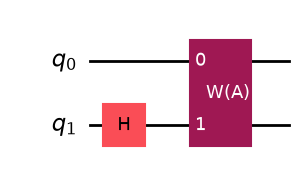

In [43]:
# Example: block-encode a simple 2 by 2 matrix A = 0.5 Z.


# System operator A = 0.5 Z
Z = np.array([
    [1, 0],
    [0, -1],
], dtype=complex)

I = np.eye(2, dtype=complex)  # 2 by 2 identity matrix

A = 0.5 * Z
defect = np.sqrt(1 - 0.5**2) * I

# This is a block-encoding of A:
#
# W(A) = [[A, i sqrt(I-A^2)],
#         [i sqrt(I-A^2), A]]
#
# Therefore:
#
# (<0| ⊗ I) W(A) (|0> ⊗ I) = A
#
W = np.block([
    [A, 1j * defect],
    [1j * defect, A],
])

W_gate = UnitaryGate(W, label="W(A)")

qc = QuantumCircuit(2)

# qubit 0: signal ancilla
# qubit 1: system qubit

qc.h(1)  # prepare a simple system state |psi>

qc.append(W_gate, [0, 1])

qc.draw("mpl")

### 4. Relation to QSVT and Matrix Inversion

QSP transforms eigenvalues of a Hermitian operator. QSVT extends the same idea to singular values of a general matrix.

Let the singular value decomposition of $A$ be

$$
A=W\Sigma V^\dagger,
$$

where

$$
\Sigma=\operatorname{diag}(\sigma_1,\sigma_2,\ldots),
\qquad
0\le \sigma_i\le 1.
$$

QSVT applies a polynomial to the singular values:

$$
\sigma_i \mapsto P(\sigma_i).
$$

For an odd polynomial $P$, the transformed matrix has the form

$$
P^{(\mathrm{SV})}(A)
=
W P(\Sigma)V^\dagger,
$$

where

$$
P(\Sigma)
=
\operatorname{diag}(P(\sigma_1),P(\sigma_2),\ldots).
$$

So the singular-value transformation is

$$
A=W\Sigma V^\dagger
\quad\mapsto\quad
P^{(\mathrm{SV})}(A)=W P(\Sigma)V^\dagger.
$$

The polynomial must satisfy the QSVT admissibility conditions. In particular,

$$
|P(x)|\le 1,
\qquad
x\in[-1,1],
$$

and it has a fixed parity:

$$
P(-x)=(-1)^dP(x),
$$

where $d$ is the degree of the QSP/QSVT sequence.

### Polynomial Approximation View

The reason polynomials appear is that QSP/QSVT implements polynomial transformations. A continuous target function on a closed interval can be approximated by polynomials, but QSVT also asks for boundedness and parity conditions.

For matrix inversion, the target function is

$$
f(x)=\frac{1}{x}.
$$

This function is not bounded on $[-1,1]$ and is singular at $x=0$. Therefore we do not approximate $1/x$ on the whole interval $[-1,1]$.

Instead, assume the singular values are bounded away from zero. Let

$$
\delta = \frac{1}{\kappa},
$$

where $\kappa$ is the condition number. The relevant singular-value interval is

$$
[\delta,1].
$$

For QSVT, one usually constructs an odd polynomial $p(x)$ approximating a scaled inverse on the symmetric domain

$$
[-1,-\delta]\cup[\delta,1].
$$

A standard form is

$$
\left|p(x)-\frac{\delta}{\beta x}\right|\le \epsilon',
\qquad
x\in[-1,-\delta]\cup[\delta,1].
$$

Here $\beta$ is a scaling factor chosen so that

$$
|p(x)|\le 1,
\qquad
x\in[-1,1].
$$

This is the inverse-polynomial step in QSVT linear-system algorithms. The condition number matters because smaller $\delta$ means the interval gets closer to the singularity at zero, which requires a higher-degree polynomial.

This formulation follows the QSVT linear-system discussion in Lin, *Lecture Notes on Quantum Algorithms for Scientific Computation*, arXiv:2201.08309, Section 8.4.

### Application to Matrix Inversion

For a linear system

$$
Ax=b,
$$

the target is

$$
x=A^{-1}b.
$$

Using the SVD,

$$
A^{-1}=V\Sigma^{-1}W^\dagger,
$$

where

$$
\Sigma^{-1}
=
\operatorname{diag}\left(
\frac{1}{\sigma_1},
\frac{1}{\sigma_2},
\ldots
\right).
$$

Thus matrix inversion is the singular-value transformation

$$
\sigma_i \mapsto \frac{1}{\sigma_i}.
$$

QSVT implements this by using a bounded polynomial approximation

$$
p(x)\approx \frac{\gamma}{x}
$$

on the singular-value interval of interest. Applying QSVT gives

$$
P^{(\mathrm{SV})}(A)\approx \gamma A^{-1}.
$$

For an input state $|b\rangle$, the transformed state is approximately

$$
P^{(\mathrm{SV})}(A)|b\rangle
\approx
\gamma A^{-1}|b\rangle.
$$

After normalization, this gives a quantum state proportional to the solution.


## Part II. Mathematical Setup and Unitary Realization

This part sets up the tiny Poisson matrix, normalizes it, builds the signal unitary, and chooses the polynomial used in this two-eigenvalue example.

The circuit implementation is in Part III.


### 1. From the Poisson Equation to a Matrix

The model problem is the one-dimensional Poisson equation

$$
-u''(x)=f(x),
\qquad
x\in(0,1),
$$

with homogeneous Dirichlet boundary conditions

$$
u(0)=u(1)=0.
$$

Using second-order finite differences on interior grid points gives

$$
-\frac{u_{i-1}-2u_i+u_{i+1}}{h^2}=f_i.
$$

For two interior grid points, the finite-difference matrix is, up to the common scale factor $1/h^2$,

$$
A =
\begin{pmatrix}
2 & -1 \\
-1 & 2
\end{pmatrix}.
$$

Thus the discretized problem is

$$
A u=f.
$$

The vector $f$ is the right-hand side sampled on the two interior grid points. In the code below we use

$$
f=(1,0.3)^T.
$$

The quantum input state is the normalized right-hand side

$$
|f\rangle=\frac{f}{\|f\|}.
$$

QSVT requires the encoded matrix to have norm at most one, so we normalize

$$
B=\frac{A}{\alpha},
\qquad
\alpha=4.
$$

The eigenvalues of $B$ are

$$
\frac{1}{4},\quad \frac{3}{4}.
$$

The signal unitary is built from this normalized matrix $B$:

$$
W(B)=
\begin{pmatrix}
B & i\sqrt{I-B^2} \\
i\sqrt{I-B^2} & B
\end{pmatrix}.
$$

The upper-left block of $W(B)$ is $B$.


In [44]:
def normalize(v):
    v = np.asarray(v, dtype=complex).reshape(-1)
    nrm = np.linalg.norm(v)
    if nrm == 0:
        raise ValueError('Cannot normalize the zero vector.')
    return np.real_if_close(v / nrm, tol=1000)


def fidelity(psi, phi):
    psi = normalize(psi)
    phi = normalize(phi)
    return float(abs(np.vdot(psi, phi)) ** 2)


def matrix_sqrt_psd(M, tol=1e-12):
    vals, vecs = np.linalg.eigh(np.asarray(M, dtype=complex))
    if np.min(vals) < -tol:
        raise ValueError('Matrix is not positive semidefinite.')
    vals = np.clip(vals, 0.0, None)
    return (vecs * np.sqrt(vals)) @ vecs.conj().T


def hermitian_signal_unitary(B):
    B = np.asarray(B, dtype=complex)
    dim = B.shape[0]
    I = np.eye(dim, dtype=complex)
    defect = matrix_sqrt_psd(I - B @ B)
    return np.block([[B, 1j * defect], [1j * defect, B]])


A = np.array([[2.0, -1.0], [-1.0, 2.0]])
f = np.array([1.0, 0.3])
f_state = normalize(f)
classical_solution = normalize(np.linalg.solve(A, f))

alpha = 4.0
B = A / alpha
B_eigs = np.linalg.eigvalsh(B)
lambda_min = float(np.min(np.abs(B_eigs)))
lambda_max = float(np.max(np.abs(B_eigs)))
kappa = lambda_max / lambda_min

W = hermitian_signal_unitary(B)
dim = B.shape[0]

print('A =\n', A)
print('eigenvalues(A) =', np.linalg.eigvalsh(A))
print('B = A / alpha =\n', B)
print('eigenvalues(B) =', B_eigs)
print('condition number kappa =', kappa)
print('top-left block error =', np.linalg.norm(W[:dim, :dim] - B))
print('signal-unitary error =', np.linalg.norm(W.conj().T @ W - np.eye(2 * dim)))
print('classical normalized A^{-1}|f> =', classical_solution)


A =
 [[ 2. -1.]
 [-1.  2.]]
eigenvalues(A) = [1. 3.]
B = A / alpha =
 [[ 0.5  -0.25]
 [-0.25  0.5 ]]
eigenvalues(B) = [0.25 0.75]
condition number kappa = 3.0
top-left block error = 0.0
signal-unitary error = 2.482534153247273e-16
classical normalized A^{-1}|f> = [0.8209052018 0.5710644882]


### 2. Choice of Approximating Polynomial

QSVT implements polynomial transformations, while matrix inversion needs the function $1/x$. Since $1/x$ is not a polynomial and is singular at zero, linear-system algorithms approximate a scaled inverse on the spectrum away from zero.

For this two-eigenvalue example, we choose an odd cubic polynomial

$$
p(x)=a x + b x^3
$$

and set it to match the scaled inverse at the two eigenvalues of $B$.

Choose

$$
\gamma=\frac{3}{32}.
$$

The matching conditions are

$$
p\left(\frac{1}{4}\right)=\frac{\gamma}{1/4},
\qquad
p\left(\frac{3}{4}\right)=\frac{\gamma}{3/4}.
$$

Solving gives

$$
p(x)=\frac{5}{3}x-\frac{8}{3}x^3.
$$

This choice is tied to the two-point spectrum. A larger Poisson matrix would require an approximation over a full spectral interval.


In [45]:
gamma = 3.0 / 32.0


def inverse_polynomial(x):
    x = np.asarray(x)
    return (5.0 / 3.0) * x - (8.0 / 3.0) * x**3


for x in B_eigs:
    print(f'x = {x:.2f}, p(x) = {inverse_polynomial(x):.10f}, gamma / x = {gamma / x:.10f}')

xs = np.linspace(-1.0, 1.0, 2001)
print('sampled max |p(x)| on [-1, 1] =', np.max(np.abs(inverse_polynomial(xs))))

pB_direct = (5.0 / 3.0) * B - (8.0 / 3.0) * (B @ B @ B)
polynomial_state = normalize(pB_direct @ f_state)

print('normalized p(B)|f> =', polynomial_state)
print('classical normalized A^{-1}|f> =', classical_solution)
print('fidelity =', fidelity(polynomial_state, classical_solution))


x = 0.25, p(x) = 0.3750000000, gamma / x = 0.3750000000
x = 0.75, p(x) = 0.1250000000, gamma / x = 0.1250000000
sampled max |p(x)| on [-1, 1] = 0.9999999999999998
normalized p(B)|f> = [0.8209052018 0.5710644882]
classical normalized A^{-1}|f> = [0.8209052018 0.5710644882]
fidelity = 1.0


### 3. Matrix-Level QSP/QSVT Unitary

For this polynomial, use the precomputed degree-3 QSP phases

$$
\Phi = [0.00818588, -0.61547971, 0.61547971, 3.13340678].
$$

The matrix-level sequence is

$$
U_\Phi(B)
=
S(\phi_0)W(B)S(\phi_1)W(B)S(\phi_2)W(B)S(\phi_3).
$$

Its upper-left block approximates $p(B)$.


In [46]:
phases = np.array([0.00818588, -0.61547971, 0.61547971, 3.13340678])


def phase_operator(phi, dim):
    I = np.eye(dim, dtype=complex)
    return np.block([
        [np.exp(1j * phi) * I, np.zeros((dim, dim), dtype=complex)],
        [np.zeros((dim, dim), dtype=complex), np.exp(-1j * phi) * I],
    ])


def qsvt_sequence(signal_unitary, phases, dim):
    U = phase_operator(phases[0], dim)
    for phi in phases[1:]:
        U = U @ signal_unitary @ phase_operator(phi, dim)
    return U


U_qsvt = qsvt_sequence(W, phases, dim)
pB_from_qsvt = U_qsvt[:dim, :dim]

print('QSVT unitarity error =', np.linalg.norm(U_qsvt.conj().T @ U_qsvt - np.eye(2 * dim)))
print('||top-left block - p(B)|| =', np.linalg.norm(pB_from_qsvt - pB_direct))


QSVT unitarity error = 6.676820358421131e-16
||top-left block - p(B)|| = 3.2417018335939676e-09


## Part III. Quantum Circuit for the Tiny Matrix Equation

This part turns the matrix-level construction into a Qiskit circuit.

The system qubit stores the normalized right-hand side

$$
|f\rangle=\frac{f}{\|f\|}.
$$

The matrix used by the QSP/QSVT sequence is

$$
B=\frac{A}{\alpha},
$$

where $A$ is the two-point Poisson matrix and $\alpha=4$. The gate $W(B)$ is the signal unitary whose upper-left block is $B$.

The circuit prepares $|f\rangle$ on the system qubit, applies the QSP/QSVT sequence using the signal ancilla, and postselects the ancilla-$|0\rangle$ component. With the phase sequence chosen above, that component is

$$
p(B)|f\rangle = \gamma B^{-1}|f\rangle.
$$

Since $B=A/\alpha$, this state is proportional to

$$
A^{-1}|f\rangle.
$$

The circuit uses $W(B)$ as one unitary gate. Decomposition of $W(B)$ into elementary gates is outside this notebook.


### 1. Build and Draw the QSVT Circuit

The circuit below is the gate-level version of the matrix product

$$
U_\Phi(B)
=
S(\phi_0)W(B)S(\phi_1)W(B)S(\phi_2)W(B)S(\phi_3).
$$

Here `q_0` is the signal ancilla and `q_1` is the system qubit. The system qubit is initialized to

$$
|f\rangle = f / \|f\|.
$$

This state preparation step is handled by Qiskit's `initialize` routine in the demo. Since the example has only two entries,

$$
f=(f_0,f_1)^T,
$$

the normalized state has the form

$$
|f\rangle = a|0\rangle + b|1\rangle,
\qquad
(a,b)=f/\|f\|.
$$

For real nonnegative amplitudes, this can be prepared by a Bloch-sphere rotation

$$
R_y(\theta)|0\rangle
=
\cos(\theta/2)|0\rangle+\sin(\theta/2)|1\rangle,
$$

with

$$
\theta = 2\arctan(b/a).
$$

Qiskit's `initialize` hides this small decomposition. In a larger PDE problem, preparing

$$
|f\rangle = \sum_i f_i |i\rangle / \|f\|
$$

is a separate algorithmic task. Its cost depends on how the data $f_i$ is provided, for example by an oracle, by a QRAM-like model, or by exploitable structure in the right-hand side.

Each factor $S(\phi_j)$ is applied to the signal ancilla `q_0`. Qiskit implements

$$
S(\phi)=e^{i\phi Z}
$$

as

$$
R_z(-2\phi),
$$

because $R_z(\theta)=\operatorname{diag}(e^{-i\theta/2}, e^{i\theta/2})$.

Qiskit uses a little-endian qubit convention. The matrix $W(B)$ above is written with the signal ancilla as the block index, so the gate is appended to the qubits as `[system, signal]`, i.e. `[1, 0]`.

The circuit uses $W(B)$ as one unitary gate. Decomposition of $W(B)$ into elementary gates is outside this notebook.


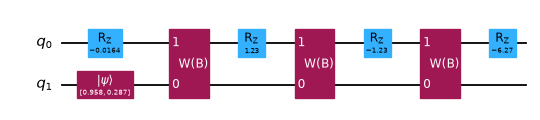

In [47]:
# W is the signal unitary W(B) built from the normalized Poisson matrix B = A / alpha.
W_gate_poisson = UnitaryGate(W, label='W(B)')

qc_qsvt = QuantumCircuit(2)

# qubit 0: signal ancilla
# qubit 1: system qubit
# Prepare |f> = f / ||f|| on the system qubit.
qc_qsvt.initialize(f_state, [1])

# These phases encode the chosen polynomial p(x).
for i, phi in enumerate(phases):
    qc_qsvt.rz(-2 * phi, 0)
    if i < len(phases) - 1:
        # The qargs order [1, 0] matches the block convention used for W(B).
        qc_qsvt.append(W_gate_poisson, [1, 0])

qc_qsvt.draw('mpl', scale=0.65, fold=-1, idle_wires=False)


### 2. Simulate and Postselect

After the QSVT circuit, the two-qubit state has the form

$$
|\Psi\rangle
=
|0\rangle_{q_0} \otimes p(B)|f\rangle_{q_1}
+
|1\rangle_{q_0} \otimes |\mathrm{bad}\rangle_{q_1},
$$

up to the scaling and approximation error from the chosen polynomial.

A real quantum run measures only the signal ancilla `q_0`. If the outcome is `0`, the remaining system register `q_1` is kept and is proportional to

$$
p(B)|f\rangle \approx \gamma B^{-1}|f\rangle.
$$

Since $B=A/\alpha$, this is proportional to $A^{-1}f$, the solution vector of the original linear system. If the outcome is `1`, that run is discarded or one uses amplitude amplification to improve the success probability.

The statevector simulation below does not perform physical measurement. It directly extracts the ancilla-`0` amplitudes. In Qiskit's little-endian ordering, these are indices `0` and `2`, corresponding to the two basis states of the system qubit `q_1`.


In [48]:
def drop_tiny_imaginary_parts(vector, tolerance=1e-8):
    vector = np.asarray(vector)
    if np.max(np.abs(vector.imag)) < tolerance:
        return vector.real
    return vector


statevector = Statevector.from_instruction(qc_qsvt).data
postselected_system = np.array([statevector[0], statevector[2]])
success_probability = np.linalg.norm(postselected_system) ** 2
qsvt_solution = normalize(drop_tiny_imaginary_parts(postselected_system))
expected_from_polynomial = pB_direct @ f_state

print('postselection probability =', success_probability)
print('QSVT circuit solution state =', qsvt_solution)
print('normalized p(B)|f> =', normalize(expected_from_polynomial))
print('||circuit postselection - p(B)|f>|| =', np.linalg.norm(postselected_system - expected_from_polynomial))
print('classical solution state =', classical_solution)
print('fidelity =', fidelity(qsvt_solution, classical_solution))


postselection probability = 0.1125286689490158
QSVT circuit solution state = [0.8209052008 0.5710644896]
normalized p(B)|f> = [0.8209052018 0.5710644882]
||circuit postselection - p(B)|f>|| = 2.5105896990991503e-09
classical solution state = [0.8209052018 0.5710644882]
fidelity = 1.0000000000000004
